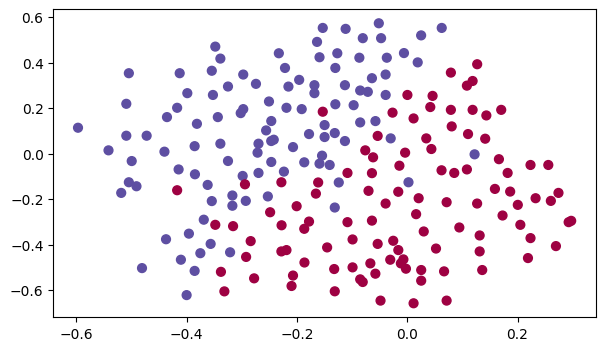

In [2]:
# import packages
import numpy as np
import matplotlib.pyplot as plt
from model_utils import *
import sklearn
import sklearn.datasets
import scipy.io
from testCases import *
import h5py

%matplotlib inline
plt.rcParams['figure.figsize'] = (7.0, 4.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

train_X, train_Y, test_X, test_Y = load_2D_dataset()

Each point on the field represents where a player headed the ball after the French goalkeeper kicked it from the left side.

* A **blue dot** means a French player made the header
* A **red dot** means an opposing player got to it instead

The task is to use a deep learning model to figure out the best areas on the field where the goalkeeper should aim their kicks.

### Understanding the data

The dataset isn’t perfect, but there’s a clear pattern: a diagonal boundary roughly separates the regions where French players win the ball (upper left) from where the opponents do (lower right).

### Model approach

You’ll start with a basic neural network **without any regularization**.

This model can later be adapted in two ways:

* **L2 regularization** by setting `lambd` to a non-zero value
* **Dropout** by setting `keep_prob` to less than 1

### What you’ll do

1. Run the model without regularization
2. Then improve it by adding:

   * L2 regularization

     * `compute_cost_with_regularization()`
     * `backward_propagation_with_regularization()`
   * Dropout

     * `forward_propagation_with_dropout()`
     * `backward_propagation_with_dropout()`

At each step, you’ll plug your implementations into the model and observe how performance changes.




## L2 Regularization

The standard way to avoid overfitting is called **L2 regularization**. It works by modifying the cost function to penalize large weights.

---

### Original Cost Function

$$
J = -\frac{1}{m} \sum_{i=1}^{m} \left( y^{(i)} \log(a^{[L](i)}) + (1 - y^{(i)}) \log(1 - a^{[L](i)}) \right)
$$

---

### Regularized Cost Function

$$
J_{\text{regularized}} =
-\frac{1}{m} \sum_{i=1}^{m} \left( y^{(i)} \log(a^{[L](i)}) + (1 - y^{(i)}) \log(1 - a^{[L](i)}) \right)
+ \frac{\lambda}{2m} \sum_{l} \sum_{k} \sum_{j} \left(W^{[l]}_{k,j}\right)^2
$$

---

### Explanation

- The first term is the **cross-entropy loss**
- The second term is the **L2 regularization penalty**
- \( \lambda \) controls how strong the penalty is
- Larger weights increase the cost, forcing the model to stay simple and avoid overfitting

---

### Expanded L2 Term (for this network)

Since your network has three layers, the regularization term becomes:

$$
\text{L2 term} = \frac{\lambda}{2m} \left(
\sum W^{[1]^2} + \sum W^{[2]^2} + \sum W^{[3]^2}
\right)
$$



In [ ]:
def compute_cost_with_regularization(A3, Y, parameters, lambd):
    m = Y.shape[1]
    W1 = parameters["W1"]
    W2 = parameters["W2"]
    W3 = parameters["W3"]

    cross_entropy_cost = compute_cost(A3, Y)
    L2_regularization_cost = lambd/(2*m)*(np.sum(np.square(W1))+np.sum(np.square(W2))+np.sum(np.square(W3)))
    cost = cross_entropy_cost + L2_regularization_cost
    return cost

A3, Y_assess, parameters = compute_cost_with_regularization_test_case()
print("cost = " + str(compute_cost_with_regularization(A3, Y_assess, parameters, lambd = 0.1)))

cost = 1.7864857919498398


In [9]:
def backward_propagation_with_regularization(X, Y, cache, lambd):
    m = X.shape[1]
    (Z1, A1, W1, b1, Z2, A2, W2, b2, Z3, A3, W3, b3) = cache

    dZ3 = A3 - Y
    dW3 = (1./m) * np.dot(dZ3, A2.T) + (lambd/m) * W3
    db3 = (1./m) * np.sum(dZ3, axis=1, keepdims=True)

    dA2 = np.dot(W3.T, dZ3)
    dZ2 = dA2 * (A2 > 0)
    dW2 = (1./m) * np.dot(dZ2, A1.T) + (lambd/m) * W2
    db2 = (1./m) * np.sum(dZ2, axis=1, keepdims=True)

    dA1 = np.dot(W2.T, dZ2)
    dZ1 = dA1 * (A1 > 0)
    dW1 = (1./m) * np.dot(dZ1, X.T) + (lambd/m) * W1
    db1 = (1./m) * np.sum(dZ1, axis=1, keepdims=True)

    return {"dZ3": dZ3, "dW3": dW3, "db3": db3,
            "dA2": dA2, "dZ2": dZ2, "dW2": dW2, "db2": db2,
            "dA1": dA1, "dZ1": dZ1, "dW1": dW1, "db1": db1}

X_assess, Y_assess, cache = backward_propagation_with_regularization_test_case()
grads = backward_propagation_with_regularization(X_assess, Y_assess, cache, lambd=0.7)
print ("dW1 = \n"+ str(grads["dW1"]))
print ("dW2 = \n"+ str(grads["dW2"]))
print ("dW3 = \n"+ str(grads["dW3"]))

dW1 = 
[[-0.25604646  0.12298827 -0.28297129]
 [-0.17706303  0.34536094 -0.4410571 ]]
dW2 = 
[[ 0.79276486  0.85133918]
 [-0.0957219  -0.01720463]
 [-0.13100772 -0.03750433]]
dW3 = 
[[-1.77691347 -0.11832879 -0.09397446]]


Expected Output:

dW1 = 
[[-0.25604646  0.12298827 -0.28297129]
 [-0.17706303  0.34536094 -0.4410571 ]]

dW2 = 
[[ 0.79276486  0.85133918]
 [-0.0957219  -0.01720463]
 [-0.13100772 -0.03750433]]
 
dW3 = 
[[-1.77691347 -0.11832879 -0.09397446]]

Let's now run the model with L2 regularization  (λ=0.7)
 . The model() function will call:

`compute_cost_with_regularization` instead of `compute_cost`
`backward_propagation_with_regularization` instead of `backward_propagation`

In [ ]:
def forward_propagation_with_dropout(X, parameters, keep_prob = 0.5):
    np.random.seed(1)

    # retrieve parameters 
    W1, b1 = parameters["W1"], parameters["b1"]
    W2, b2 = parameters["W2"], parameters["b2"]
    W3, b3 = parameters["W3"], parameters["b3"]

    Z1 = np.dot(W1, X) + b1
    A1 = relu(Z1) 
    D1 = np.random.rand(A1.shape[0], A1.shape[1])
    D1 = (D1 < keep_prob).astype(int)
    A1 = A1 * D1
    A1 = A1/keep_prob
    
    Z2 = np.dot(W2, A1) + b2
    A2 = relu(Z2)
    D2 = np.random.rand(A2.shape[0], A2.shape[1])
    D2 = (D2 < keep_prob)
    A2 = A2*D2
    A2 = A2/keep_prob

    Z3 = np.dot(W3, A2) + b3
    A3 = sigmoid(Z3)

    return A3, (Z1, D1, A1, W1, b1, Z2, D2, A2, W2, b2, Z3, A3, W3, b3)



X, parameters = forward_propagation_with_dropout_test_case()
A3, cache = forward_propagation_with_dropout(X, parameters, keep_prob=0.7)
print ("A3 = " + str(A3))

A3 = [[0.36974721 0.00305176 0.04565099 0.49683389 0.36974721]]


In [15]:
def backward_propagation_with_dropout(X, Y, cache, keep_prob):
    m = X.shape[1]
    (Z1, D1, A1, W1, b1, Z2, D2, A2, W2, b2, Z3, A3, W3, b3) = cache
    
    dZ3 = A3 - Y
    dW3 = (1./m) * np.dot(dZ3, A2.T)
    db3 = 1./m * np.sum(dZ3, axis=1, keepdims=True)

    dA2 = np.dot(W3.T, dZ3)

    # Apply mask D2 to shut down the same neurons as during the forward propagation 
    dA2 = D2 * dA2
    dA2 = dA2/keep_prob

    dZ2 = np.multiply(dA2, np.int64(A2 > 0))
    dW2 = (1./m) * np.dot(dZ2, A1.T)
    db2 = 1./m * np.sum(dZ2, axis=1, keepdims=True)

    dA1 = np.dot(W2.T, dZ2)
    dA1 = dA1 * D1
    dA1 = dA1/keep_prob
    dZ1 = np.multiply(dA1, np.int64(A1 > 0))
    dW1 = (1./m) * np.dot(dZ1, X.T)
    db1 = 1./m * np.sum(dZ1, axis=1, keepdims=True)

    return {"dZ3": dZ3, "dW3": dW3, "db3": db3,
            "dA2": dA2, "dZ2": dZ2, "dW2": dW2, "db2": db2,
            "dA1": dA1, "dZ1": dZ1, "dW1": dW1, "db1": db1}

X_assess, Y_assess, cache = backward_propagation_with_dropout_test_case()

gradients = backward_propagation_with_dropout(X_assess, Y_assess, cache, keep_prob = 0.8)

print ("dA1 = \n" + str(gradients["dA1"]))
print ("dA2 = \n" + str(gradients["dA2"]))

dA1 = 
[[ 0.36544439  0.         -0.00188233  0.         -0.17408748]
 [ 0.65515713  0.         -0.00337459  0.         -0.        ]]
dA2 = 
[[ 0.58180856  0.         -0.00299679  0.         -0.27715731]
 [ 0.          0.53159854 -0.          0.53159854 -0.34089673]
 [ 0.          0.         -0.00292733  0.         -0.        ]]


## Backward Propagation with Dropout

In dropout, some neurons are randomly "turned off" during forward propagation.  
During backpropagation, you must apply the **same pattern** so gradients flow only through the active neurons.

---

### Key Idea

Dropout affects both:
- Forward propagation → activations are masked and scaled  
- Backward propagation → gradients must be masked and scaled the same way  

---

### Steps for Backpropagation with Dropout

#### Step 1: Apply the dropout mask

During forward propagation, you used a mask \( D^{[1]} \) to shut down some neurons in \( A^{[1]} \).

So during backpropagation, apply the same mask to the gradient:

$$
dA^{[1]} = dA^{[1]} * D^{[1]}
$$

Similarly for layer 2:

$$
dA^{[2]} = dA^{[2]} * D^{[2]}
$$

---

#### Step 2: Scale the gradients

In forward propagation, you scaled activations by dividing by \( \text{keep\_prob} \):

$$
A^{[1]} = \frac{A^{[1]}}{\text{keep\_prob}}
$$

So in backpropagation, you must scale the gradients the same way:

$$
dA^{[1]} = \frac{dA^{[1]}}{\text{keep\_prob}}
$$

$$
dA^{[2]} = \frac{dA^{[2]}}{\text{keep\_prob}}
$$

---

### Why This Matters

- If you don’t apply the mask → gradients flow through neurons that were supposed to be off  
- If you don’t scale → your gradients become inconsistent with forward propagation  

Either way, your model quietly breaks while pretending everything is fine. Which is honestly the most dangerous kind of bug.

---

### Implementation Summary

For each hidden layer (1 and 2):

1. Apply mask:

cost after 0 iterations: 0.655741
cost after 3000 iterations: 0.182515
cost after 6000 iterations: 0.168327
cost after 9000 iterations: 0.159426
cost after 12000 iterations: 0.157645
cost after 15000 iterations: 0.147964
cost after 18000 iterations: 0.143351
cost after 21000 iterations: 0.141187
cost after 24000 iterations: 0.130323
cost after 27000 iterations: 0.132638


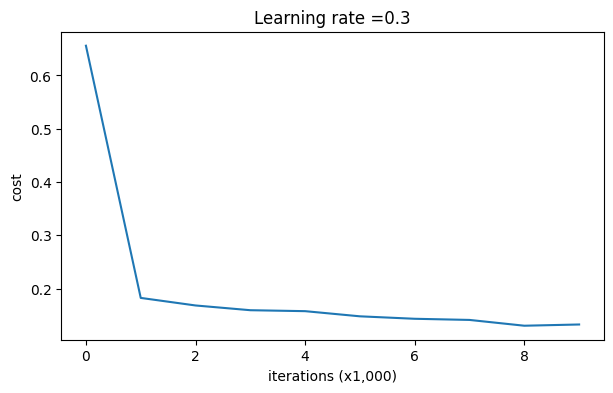

On the training set:
Accuracy: 0.9478672985781991
On the test set:
Accuracy: 0.915


In [23]:
def model(X, Y, learning_rate = 0.3, num_iterations = 30000, print_cost = True, lambd = 0, keep_prob = 1):
    grads = {}
    costs = [] # keep track of the cost
    layers_dims = [X.shape[0], 20, 3, 1] 
    m = X.shape[1] # No. of training samples

    parameters = initialize_parameters(layers_dims)

    for i  in range(0, num_iterations):
        # forward propagation 
        if keep_prob == 1:
            A3, cache = forward_propagation(X, parameters)
        elif keep_prob < 1:
            A3, cache = forward_propagation_with_dropout(X, parameters, keep_prob)
        
        # cost function 
        if lambd == 0:
            cost = compute_cost(A3, Y)
        else:
            cost = compute_cost_with_regularization(A3, Y, parameters, lambd)

        # Backward propagation.
        assert(lambd==0 or keep_prob==1)

        if lambd == 0 and keep_prob == 1:
            grads = backward_propagation(X, Y, cache)
        elif lambd != 0:
            grads = backward_propagation_with_regularization(X, parameters, lambd)
        elif keep_prob < 1:
            grads = backward_propagation_with_dropout(X, Y, cache, keep_prob)
        
        # Update parameters.
        parameters = update_parameters(parameters, grads, learning_rate)

        if  print_cost and i%3000 == 0:
            costs.append(cost)
            print(f"cost after {i} iterations: {cost:.6f}")
    # plot the cost
    plt.plot(costs)
    plt.ylabel('cost')
    plt.xlabel('iterations (x1,000)')
    plt.title("Learning rate =" + str(learning_rate))
    plt.show()

    return parameters

parameters = model(train_X, train_Y)
print ("On the training set:")
predictions_train = predict(train_X, train_Y, parameters)
print ("On the test set:")
predictions_test = predict(test_X, test_Y, parameters)


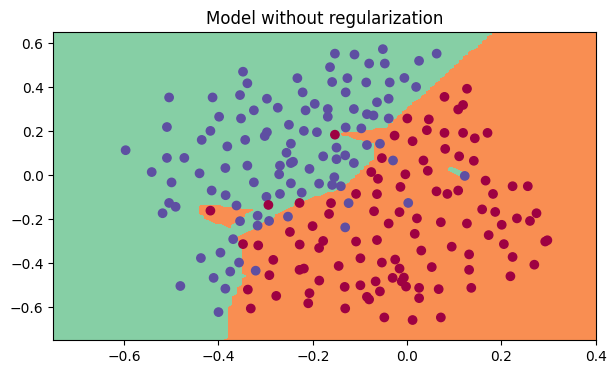

In [24]:
# Model without regularization
plt.title("Model without regularization")
axes = plt.gca()
axes.set_xlim([-0.75,0.40])
axes.set_ylim([-0.75,0.65])
plot_decision_boundary(lambda x: predict_dec(parameters, x.T), train_X, train_Y)

### Non-Regularized Model

You’ll start with a neural network that’s already been implemented for you.

This model has two optional modes:

* **Regularization mode**: activated by setting `lambd` to a value greater than 0
  *(they avoided calling it “lambda” because Python would throw a tantrum)*
* **Dropout mode**: activated by setting `keep_prob` to a value less than 1

### What you need to do

1. **First**, run the model *without* any regularization
   (basically let it overfit like it’s emotionally attached to the training data)

2. **Then**, improve the model by adding:

   **L2 Regularization**

   * `compute_cost_with_regularization()`
   * `backward_propagation_with_regularization()`

   **Dropout**

   * `forward_propagation_with_dropout()`
   * `backward_propagation_with_dropout()`

At each stage, you’ll run the model with the right parameters so it actually uses the functions you implemented, instead of politely ignoring your work.
Before diving in, go through the provided code so you don’t blindly wire things together and then wonder why nothing works.


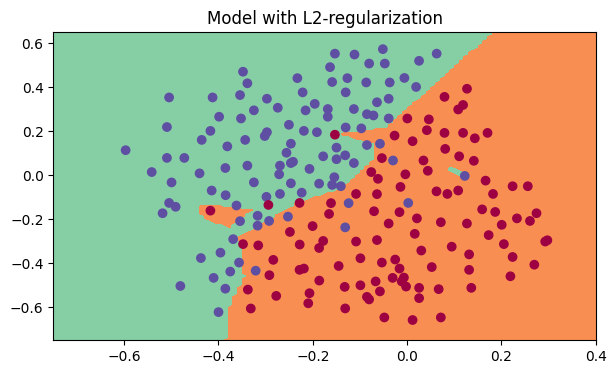

In [25]:
# Model with L2-regularization
plt.title("Model with L2-regularization")
axes = plt.gca()
axes.set_xlim([-0.75,0.40])
axes.set_ylim([-0.75,0.65])
plot_decision_boundary(lambda x: predict_dec(parameters, x.T), train_X, train_Y)

Observations:

The value of  λ
  is a hyperparameter that you can tune using a dev set.
L2 regularization makes your decision boundary smoother. If  λ
  is too large, it is also possible to "oversmooth", resulting in a model with high bias.
What is L2-regularization actually doing?:

L2-regularization relies on the assumption that a model with small weights is simpler than a model with large weights. Thus, by penalizing the square values of the weights in the cost function you drive all the weights to smaller values. It becomes too costly for the cost to have large weights! This leads to a smoother model in which the output changes more slowly as the input changes

cost after 0 iterations: 0.654391
cost after 3000 iterations: 0.076613
cost after 6000 iterations: 0.062410
cost after 9000 iterations: 0.061192
cost after 12000 iterations: 0.060826
cost after 15000 iterations: 0.060665
cost after 18000 iterations: 0.060659
cost after 21000 iterations: 0.060559
cost after 24000 iterations: 0.060504
cost after 27000 iterations: 0.060473


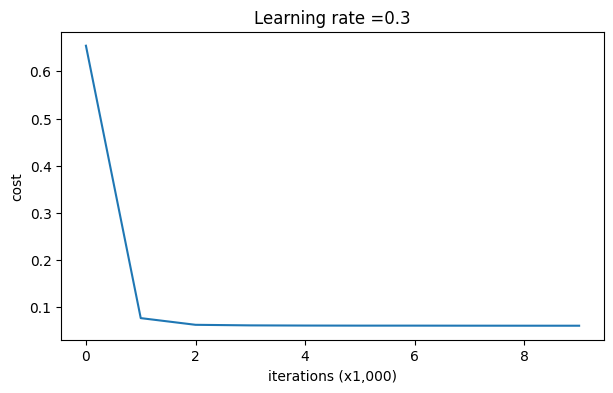

On the train set:
Accuracy: 0.9289099526066351
On the test set:
Accuracy: 0.95


In [26]:
parameters = model(train_X, train_Y, keep_prob = 0.86, learning_rate = 0.3)

print ("On the train set:")
predictions_train = predict(train_X, train_Y, parameters)
print ("On the test set:")
predictions_test = predict(test_X, test_Y, parameters)

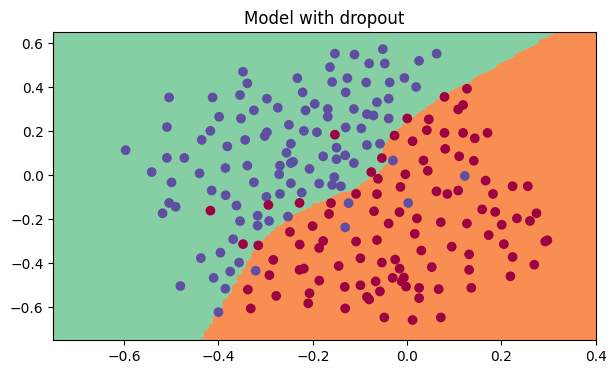

In [27]:
plt.title("Model with dropout")
axes = plt.gca()
axes.set_xlim([-0.75,0.40])
axes.set_ylim([-0.75,0.65])
plot_decision_boundary(lambda x: predict_dec(parameters, x.T), train_X, train_Y)